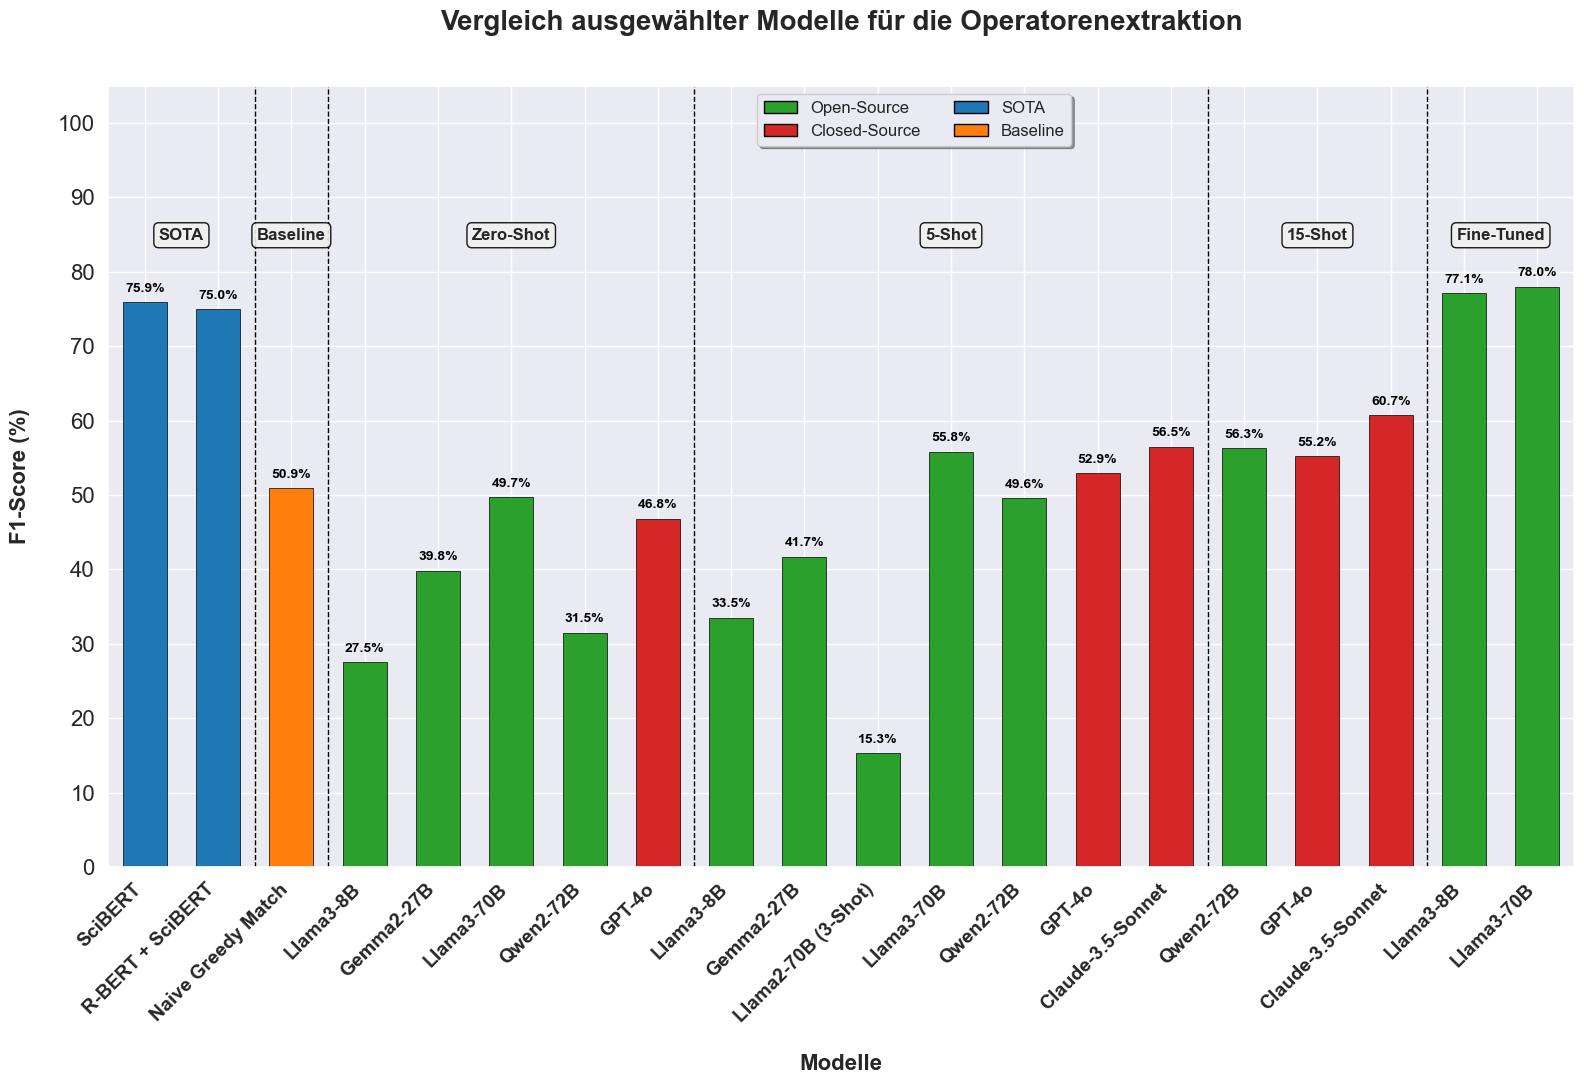

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch

In [ ]:
data = {
    'Model': [
        'SciBERT', 'R-BERT + SciBERT', 'Naive Greedy Match',
        'Llama3-8B', 'Gemma2-27B', 'Llama3-70B', 'Qwen2-72B', 'GPT-4o',
        'Llama3-8B', 'Gemma2-27B', 'Llama2-70B (3-Shot)', 'Llama3-70B', 'Qwen2-72B', 'GPT-4o', 'Claude-3.5-Sonnet',
        'Qwen2-72B', 'GPT-4o', 'Claude-3.5-Sonnet',
        'Llama3-8B', 'Llama3-70B'
    ],
    'F1': [
        75.9, 75.0, 50.9, 27.5, 39.8, 49.7, 31.5, 46.8,
        33.5, 41.7, 15.3, 55.8, 49.6, 52.9, 56.5, 56.3,
        55.2, 60.7, 77.1, 78.0
    ],
    'Type': [
        'SOTA', 'SOTA', 'Baseline',
        'Zero-Shot', 'Zero-Shot', 'Zero-Shot', 'Zero-Shot', 'Zero-Shot',
        '5-Shot', '5-Shot', '5-Shot', '5-Shot', '5-Shot', '5-Shot', '5-Shot',
        '15-Shot', '15-Shot', '15-Shot',
        'Fine-Tuned', 'Fine-Tuned'
    ],
    'Open_Closed': [
        'Closed', 'Closed', 'Open',
        'Open', 'Open', 'Open', 'Open', 'Closed',
        'Open', 'Open', 'Open', 'Open', 'Open', 'Closed', 'Closed',
        'Open', 'Closed', 'Closed',
        'Open', 'Open'
    ]
}

In [ ]:
df = pd.DataFrame(data)
sns.set_theme(style="darkgrid")
color_palette = {
    'SOTA': '#1f77b4',
    'Baseline': '#ff7f0e',
    'Open': '#2ca02c',
    'Closed': '#d62728'
}

def get_bar_color(row):
    if row['Type'] == 'SOTA':
        return color_palette['SOTA']
    elif row['Type'] == 'Baseline':
        return color_palette['Baseline']
    elif row['Open_Closed'] == 'Open':
        return color_palette['Open']
    else:
        return color_palette['Closed']

df['Color'] = df.apply(get_bar_color, axis=1)
fig, ax = plt.subplots(figsize=(16, 11))
bar_positions = np.arange(len(df))
bar_width = 0.6
bars = ax.bar(
    bar_positions,
    df['F1'],
    bar_width,
    align='center',
    color=df['Color'],
    edgecolor='black',
    linewidth=0.5
)
def add_value_labels(ax, df):
    for i, rect in enumerate(ax.patches[:len(df)]):
        height = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        ax.text(x_value, height + 1, f"{height:.1f}%",
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

add_value_labels(ax, df)
ax.set_xlabel('Modelle', fontsize=16, fontweight='bold', labelpad=20)
ax.set_ylabel('F1-Score (%)', fontsize=16, fontweight='bold', labelpad=20)
ax.set_title('Vergleich ausgewählter Modelle für die Operatorenextraktion', fontsize=20, fontweight='bold', pad=40)
ax.set_xticks(bar_positions)
ax.set_xticklabels(df['Model'], rotation=45, ha='right', fontsize=14, fontweight='bold')

legend_elements = [
    Patch(facecolor=color_palette['Open'], edgecolor='black', label='Open-Source'),
    Patch(facecolor=color_palette['Closed'], edgecolor='black', label='Closed-Source'),
    Patch(facecolor=color_palette['SOTA'], edgecolor='black', label='SOTA'),
    Patch(facecolor=color_palette['Baseline'], edgecolor='black', label='Baseline')
]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center', bbox_to_anchor=(0.55, 1.00), ncol=2, frameon=True, fancybox=True, shadow=True)


type_boundaries = df['Type'].ne(df['Type'].shift()).cumsum()
for idx, group in df.groupby(type_boundaries):
    start = group.index[0] - 0.5
    end = group.index[-1] + 0.5
    if group['Type'].iloc[0] == 'Baseline':
        text_position = start + (end - start) / 2
    else:
        text_position = start + (end - start) / 2
    ax.text(
        text_position,
        ax.get_ylim()[1] + 2,
        group['Type'].iloc[0],
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        bbox=dict(facecolor='#f0f0f0', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.3')
    )
    ax.axvline(end, color='black', linestyle='--', linewidth=1)


ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 110, 10))
ax.tick_params(axis='y', labelsize=16, width=1.5)
ax.set_xlim(-0.5, len(df) - 0.5)
plt.tight_layout()
plt.savefig('pics/operator_auswertung3.svg', format='svg', bbox_inches='tight')
plt.show()

C:\Users\e-aut\AppData\Local\Temp\ipykernel_2964\2306527415.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


<Figure size 2000x1000 with 0 Axes>

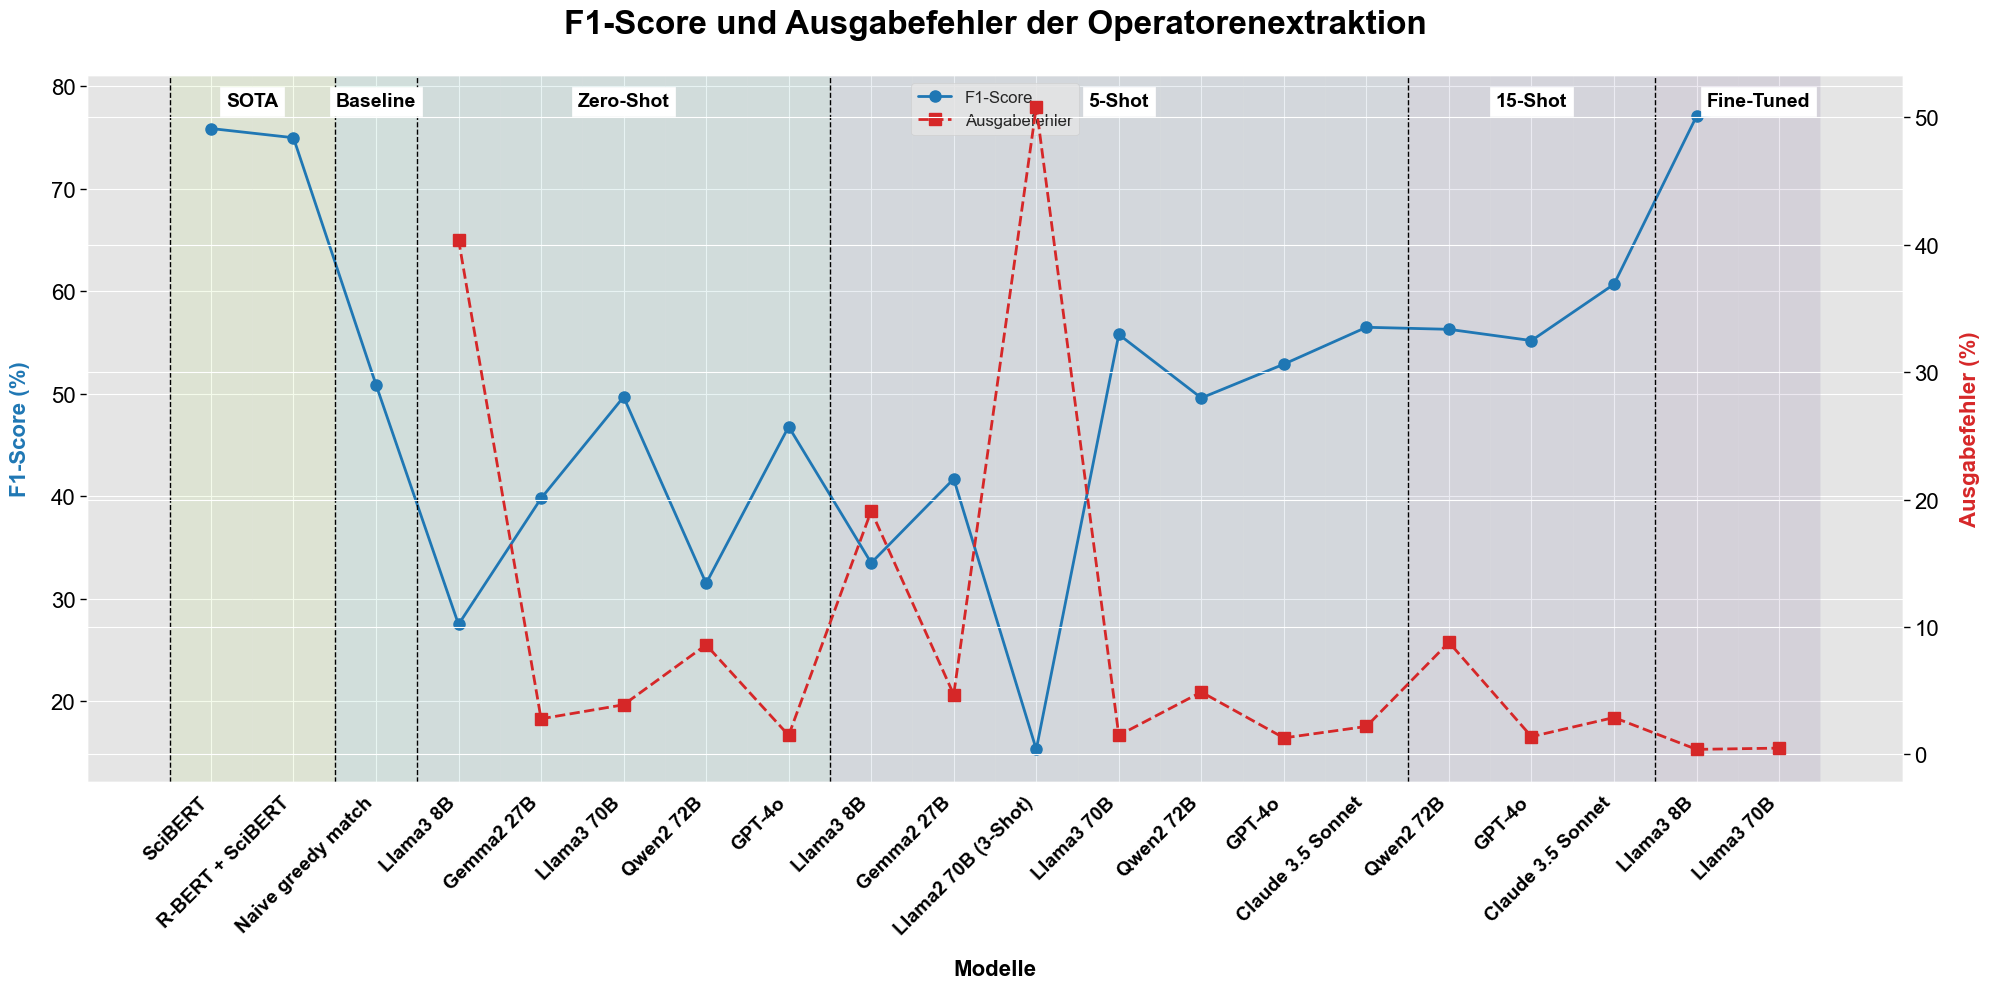

In [4]:
## Same Plot as Parallel Coordinates
data = {
    'Model': ['SciBERT', 'R-BERT + SciBERT', 'Naive greedy match', 'Llama3 8B', 'Gemma2 27B (Zero-Shot)', 'Llama3 70B (Zero-Shot)', 'Qwen2 72B (Zero-Shot)', 'GPT-4o (Zero-Shot)', 'Llama3 8B (5-Shot)', 'Gemma2 27B (5-Shot)', 'Llama2 70B (3-Shot)', 'Llama3 70B (5-Shot)', 'Qwen2 72B (5-Shot)', 'GPT-4o (5-Shot)', 'Claude 3.5 Sonnet (5-Shot)', 'Qwen2 72B (15-Shot)', 'GPT-4o (15-Shot)', 'Claude 3.5 Sonnet (15-Shot)', 'Llama3 8B (Fine-Tuned)', 'Llama3 70B (Fine-Tuned)'],
    'F1': [75.9, 75.0, 50.9, 27.5, 39.8, 49.7, 31.5, 46.8, 33.5, 41.7, 15.3, 55.8, 49.6, 52.9, 56.5, 56.3, 55.2, 60.7, 77.1, 78.0],
    'Ausgabefehler': [np.nan, np.nan, np.nan, 40.4, 2.8, 3.9, 8.6, 1.5, 19.1, 4.7, 50.8, 1.5, 4.9, 1.3, 2.2, 8.8, 1.4, 2.9, 0.4, 0.5],
    'Type': ['SOTA', 'SOTA', 'Baseline', 'Zero-Shot', 'Zero-Shot', 'Zero-Shot', 'Zero-Shot', 'Zero-Shot', '5-Shot', '5-Shot', '5-Shot', '5-Shot', '5-Shot', '5-Shot', '5-Shot', '15-Shot', '15-Shot', '15-Shot', 'Fine-Tuned', 'Fine-Tuned']
}

df = pd.DataFrame(data)

# Funktion zum Entfernen von Text in Klammern
def remove_parentheses(text):
    if 'Llama2 70B' in text:
        return text
    return re.sub(r'\([^)]*\)', '', text).strip()

# Plot erstellen
plt.figure(figsize=(20, 10))
plt.style.use('ggplot')  # ggplot-Stil für bessere Lesbarkeit

# F1-Score und Ausgabefehler in einem kombinierten Plot
fig, ax1 = plt.subplots(figsize=(20, 10))

# F1-Score plotten
ax1.set_xlabel('Modelle', fontsize=16, fontweight='bold', labelpad=15, color='black')
ax1.set_ylabel('F1-Score (%)', fontsize=16, fontweight='bold', color='tab:blue', labelpad=15)
ax1.plot(df['Model'], df['F1'], color='tab:blue', marker='o', linestyle='-', linewidth=2, markersize=8, label='F1-Score')
ax1.tick_params(axis='y', colors='black', labelsize=16)
ax1.tick_params(axis='x', colors='black', labelsize=14, labelrotation=45)

# Ausgabefehler als sekundäre Y-Achse
ax2 = ax1.twinx()
ax2.set_ylabel('Ausgabefehler (%)', fontsize=16, fontweight='bold', color='tab:red', labelpad=15)
ax2.plot(df['Model'], df['Ausgabefehler'], color='tab:red', marker='s', linestyle='--', linewidth=2, markersize=8, label='Ausgabefehler')
ax2.tick_params(axis='y', colors='black', labelsize=16)

# Titel setzen
plt.title('F1-Score und Ausgabefehler der Operatorenextraktion', fontsize=24, fontweight='bold', pad=30, color='black')

# X-Achsen-Labels bearbeiten, rotieren und ausrichten
x_labels = [remove_parentheses(label) for label in df['Model']]
ax1.set_xticks(range(len(x_labels)))
ax1.set_xticklabels(x_labels, fontsize=14, fontweight='bold', rotation=45, ha='right', color='black')

# Hintergrundfarbe basierend auf Modelltyp
cmap = plt.cm.get_cmap('viridis')
type_colors = {'SOTA': cmap(0.85), 'Baseline': cmap(0.6), 'Zero-Shot': cmap(0.5), '5-Shot': cmap(0.3), '15-Shot': cmap(0.2), 'Fine-Tuned': cmap(0.1)}

for i, (idx, row) in enumerate(df.iterrows()):
    ax1.axvspan(i - 0.5, i + 0.5, facecolor=type_colors[row['Type']], alpha=0.1)

# Legenden für F1-Score und Ausgabefehler kombinieren
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', fontsize='12', bbox_to_anchor=(0.5, 1.0))

# Verbesserte Trennlinien und Beschriftungen für Modelltypen
separations = [
    (-0.5, 'SOTA', 1.5),
    (1.5, 'Baseline', 2.5),
    (2.5, 'Zero-Shot', 7.5),
    (7.5, '5-Shot', 14.5),
    (14.5, '15-Shot', 17.5),
    (17.5, 'Fine-Tuned', 20)
]

for x_start, label, x_end in separations:
    ax1.axvline(x=x_start, color='black', linestyle='--', linewidth=1)
    ax1.text((x_start + x_end) / 2, 0.95, label, transform=ax1.get_xaxis_transform(), rotation=0,
             ha='center', va='bottom', fontsize=14, fontweight='bold', backgroundcolor='white', color='black')

plt.tight_layout()
plt.savefig('pics/line.svg', format='svg', bbox_inches='tight')
plt.show()